In [ ]:
# 1. (Updated) — Install and import libraries

# Install XGBoost
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import os, pickle, re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     RandomizedSearchCV, train_test_split)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from xgboost import XGBClassifier

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# 1A. Mount google drive with colab

from google.colab import drive
drive.mount('/content/drive')

# After mounting, verify your files are visible
import os

# Change this path to wherever your folder is in Google Drive
DATA_PATH = '/content/drive/MyDrive/EEG_Thesis/'

print("Files found in your folder:")
for f in os.listdir(DATA_PATH):
    print(f" - {f}")

In [ ]:
# 2. Setting the data path

import os

# Path to your folder in Google Drive
DATA_PATH = '/content/drive/MyDrive/EEG_Thesis/'

# List all CSV files found
all_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]

print(f"Total CSV files found: {len(all_files)}")
print("\nFiles detected:")
for f in sorted(all_files):
    print(f"  - {f}")

In [5]:
# 3. Load and label all files

import re

secondary_dfs = []
primary_dfs = []

for filename in sorted(all_files):
    filepath = os.path.join(DATA_PATH, filename)
    df = pd.read_csv(filepath)

    name_upper = filename.upper()

    # Check if filename matches secondary pattern
    # Matches: S01HI, S01LO, S10HI, S10LO, S48HI, S48LO etc.
    is_secondary = bool(re.match(r'^S\d{2,}(HI|LO)', name_upper))

    # Check if filename matches primary pattern
    # Matches: S1_, S2_, S3_, S4_ (single digit, followed by underscore)
    is_primary = bool(re.match(r'^S\d_', filename))

    # ---------- SECONDARY DATASET ----------
    if is_secondary and 'HI' in name_upper:
        df['label'] = 1
        df['subject'] = filename
        df['dataset'] = 'secondary'
        secondary_dfs.append(df)

    elif is_secondary and 'LO' in name_upper:
        df['label'] = 0
        df['subject'] = filename
        df['dataset'] = 'secondary'
        secondary_dfs.append(df)

    # ---------- PRIMARY DATASET ----------
    elif is_primary:
        df['dataset'] = 'primary'
        df['subject'] = filename
        primary_dfs.append(df)

    else:
        print(f"  WARNING — unrecognized file, skipped: {filename}")

# Combine into two master DataFrames
secondary_df = pd.concat(secondary_dfs, ignore_index=True)
primary_df   = pd.concat(primary_dfs,   ignore_index=True)

print(f"Secondary dataset: {secondary_df.shape[0]} rows, {secondary_df.shape[1]} columns")
print(f"Primary dataset:   {primary_df.shape[0]} rows, {primary_df.shape[1]} columns")
print(f"\nSecondary label counts:\n{secondary_df['label'].value_counts()}")
print(f"\nSecondary files loaded: {secondary_df['subject'].nunique()}")
print(f"Primary files loaded:   {primary_df['subject'].nunique()}")

  WARNING — unrecognized file, skipped: cv_results.csv
  WARNING — unrecognized file, skipped: cv_results_regression.csv
  WARNING — unrecognized file, skipped: final_results.csv
  WARNING — unrecognized file, skipped: final_results_regression.csv
  WARNING — unrecognized file, skipped: loso_results.csv
  WARNING — unrecognized file, skipped: primary_predictions.csv
  WARNING — unrecognized file, skipped: primary_predictions_regression.csv
Secondary dataset: 2051 rows, 73 columns
Primary dataset:   294 rows, 72 columns

Secondary label counts:
label
0    1091
1     960
Name: count, dtype: int64

Secondary files loaded: 96
Primary files loaded:   4


In [6]:
# 4. Inspect the data

print("=== SECONDARY DATASET - First 3 rows ===")
print(secondary_df.head(3))

print("\n=== PRIMARY DATASET - First 3 rows ===")
print(primary_df.head(3))

print("\n=== Column names ===")
print(secondary_df.columns.tolist())

print("\n=== Any missing values in secondary? ===")
print(secondary_df.isnull().sum().sum(), "missing values")

print("\n=== Any missing values in primary? ===")
print(primary_df.isnull().sum().sum(), "missing values")

=== SECONDARY DATASET - First 3 rows ===
   AF3_delta  AF4_delta  F3_delta  F4_delta  F7_delta  F8_delta  FC5_delta  \
0  -0.107516   0.040733 -0.629174 -0.103561 -0.177112 -0.680248   0.236184   
1  -0.911579  -1.115738 -1.401654 -1.199220 -1.246507 -0.843275  -1.482480   
2  -0.640735  -1.266312 -0.228149 -1.560238 -1.297419 -0.682789   0.254020   

   FC6_delta  T7_delta  T8_delta  ...  FC6_gamma  T7_gamma  T8_gamma  \
0  -0.130423  1.884508 -0.081378  ...   0.602784  0.485597 -0.096791   
1  -0.886550 -0.494018 -0.250587  ...  -0.129820  1.175367 -0.025550   
2  -1.317469 -0.933370 -0.195473  ...  -0.939196 -0.203451 -0.333732   

   P7_gamma  P8_gamma  O1_gamma  O2_gamma  label  \
0  0.403156  0.108637 -0.289736  0.074947      1   
1 -0.273042 -0.379531 -0.250313 -0.144924      1   
2 -0.486893 -0.620674 -0.663588 -0.920010      1   

                          subject    dataset  
0  S01HI_features_bandpower_z.csv  secondary  
1  S01HI_features_bandpower_z.csv  secondary  
2  S01H

In [7]:
# 5. Check per-subject label balance

print("=== Per-subject label counts (secondary) ===\n")

subject_check = secondary_df.groupby('subject')['label'].value_counts().unstack(fill_value=0)
subject_check.columns = ['Alert (0)', 'Fatigued (1)']
print(subject_check.to_string())

print(f"\nTotal files loaded: {secondary_df['subject'].nunique()}")
print(f"Expected: 96 files (48 subjects x 2 conditions)")

=== Per-subject label counts (secondary) ===

                                Alert (0)  Fatigued (1)
subject                                                
S01HI_features_bandpower_z.csv          0            20
S01LO_features_bandpower_z.csv         27             0
S02HI_features_bandpower_z.csv          0            17
S02LO_features_bandpower_z.csv         27             0
S03HI_features_bandpower_z.csv          0            28
S03LO_features_bandpower_z.csv         27             0
S04HI_features_bandpower_z.csv          0            12
S04LO_features_bandpower_z.csv         12             0
S05HI_features_bandpower_z.csv          0            12
S05LO_features_bandpower_z.csv         31             0
S06HI_features_bandpower_z.csv          0            28
S06LO_features_bandpower_z.csv         32             0
S07HI_features_bandpower_z.csv          0            17
S07LO_features_bandpower_z.csv         30             0
S08HI_features_bandpower_z.csv          0            18
S0

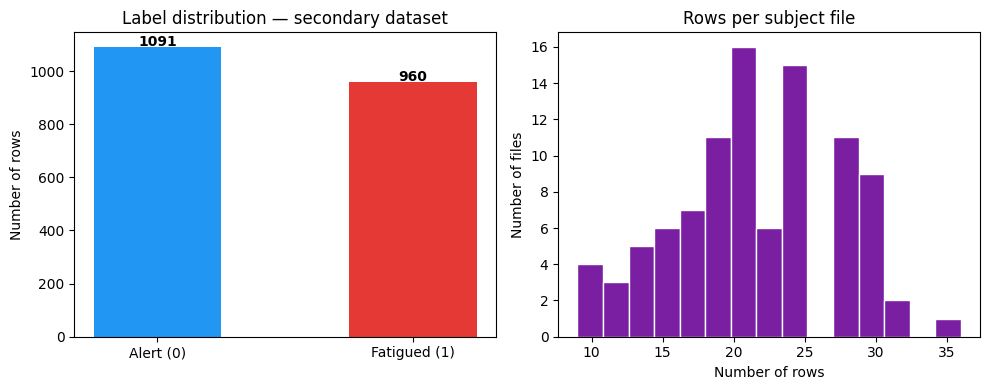

Plot saved to Google Drive!


In [8]:
# 6. visual check

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Alert (0)', 'Fatigued (1)'],
            secondary_df['label'].value_counts().sort_index(),
            color=['#2196F3', '#E53935'], width=0.5)
axes[0].set_title('Label distribution — secondary dataset')
axes[0].set_ylabel('Number of rows')
for i, v in enumerate(secondary_df['label'].value_counts().sort_index()):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

rows_per_subject = secondary_df.groupby('subject').size()
axes[1].hist(rows_per_subject, bins=15, color='#7B1FA2', edgecolor='white')
axes[1].set_title('Rows per subject file')
axes[1].set_xlabel('Number of rows')
axes[1].set_ylabel('Number of files')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Thesis/label_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Google Drive!")

In [9]:
# 7. Separate features from labels

# Define feature columns — everything except our added columns
feature_cols = [col for col in secondary_df.columns
                if col not in ['label', 'subject', 'dataset']]

print(f"Total features: {len(feature_cols)}")
print(f"\nFeature columns:\n{feature_cols}")

# Prepare X (features) and y (labels) from secondary data
X = secondary_df[feature_cols].values
y = secondary_df['label'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Total features: 70

Feature columns:
['AF3_delta', 'AF4_delta', 'F3_delta', 'F4_delta', 'F7_delta', 'F8_delta', 'FC5_delta', 'FC6_delta', 'T7_delta', 'T8_delta', 'P7_delta', 'P8_delta', 'O1_delta', 'O2_delta', 'AF3_theta', 'AF4_theta', 'F3_theta', 'F4_theta', 'F7_theta', 'F8_theta', 'FC5_theta', 'FC6_theta', 'T7_theta', 'T8_theta', 'P7_theta', 'P8_theta', 'O1_theta', 'O2_theta', 'AF3_alpha', 'AF4_alpha', 'F3_alpha', 'F4_alpha', 'F7_alpha', 'F8_alpha', 'FC5_alpha', 'FC6_alpha', 'T7_alpha', 'T8_alpha', 'P7_alpha', 'P8_alpha', 'O1_alpha', 'O2_alpha', 'AF3_beta', 'AF4_beta', 'F3_beta', 'F4_beta', 'F7_beta', 'F8_beta', 'FC5_beta', 'FC6_beta', 'T7_beta', 'T8_beta', 'P7_beta', 'P8_beta', 'O1_beta', 'O2_beta', 'AF3_gamma', 'AF4_gamma', 'F3_gamma', 'F4_gamma', 'F7_gamma', 'F8_gamma', 'FC5_gamma', 'FC6_gamma', 'T7_gamma', 'T8_gamma', 'P7_gamma', 'P8_gamma', 'O1_gamma', 'O2_gamma']

X shape: (2051, 70)
y shape: (2051,)


In [10]:
# 8. Run Random Forest to get feature importance

from sklearn.ensemble import RandomForestClassifier

# Train a quick Random Forest just for feature importance
rf_importance = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_importance.fit(X, y)

# Build a DataFrame of feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Top 20 most important features ===\n")
print(importance_df.head(20).to_string())

=== Top 20 most important features ===

      feature  importance
0    O1_alpha    0.022678
1    P7_gamma    0.021245
2    O2_gamma    0.020795
3     P8_beta    0.019699
4     F7_beta    0.018969
5    P8_gamma    0.018441
6     O2_beta    0.018196
7    P7_alpha    0.017735
8    F7_gamma    0.017321
9    O2_alpha    0.017259
10   F4_delta    0.016435
11   F4_gamma    0.016251
12   P8_alpha    0.016131
13    P7_beta    0.016058
14  FC6_gamma    0.015987
15  AF4_gamma    0.015588
16   T8_gamma    0.015514
17    O1_beta    0.015261
18   F3_gamma    0.015141
19    T7_beta    0.014951


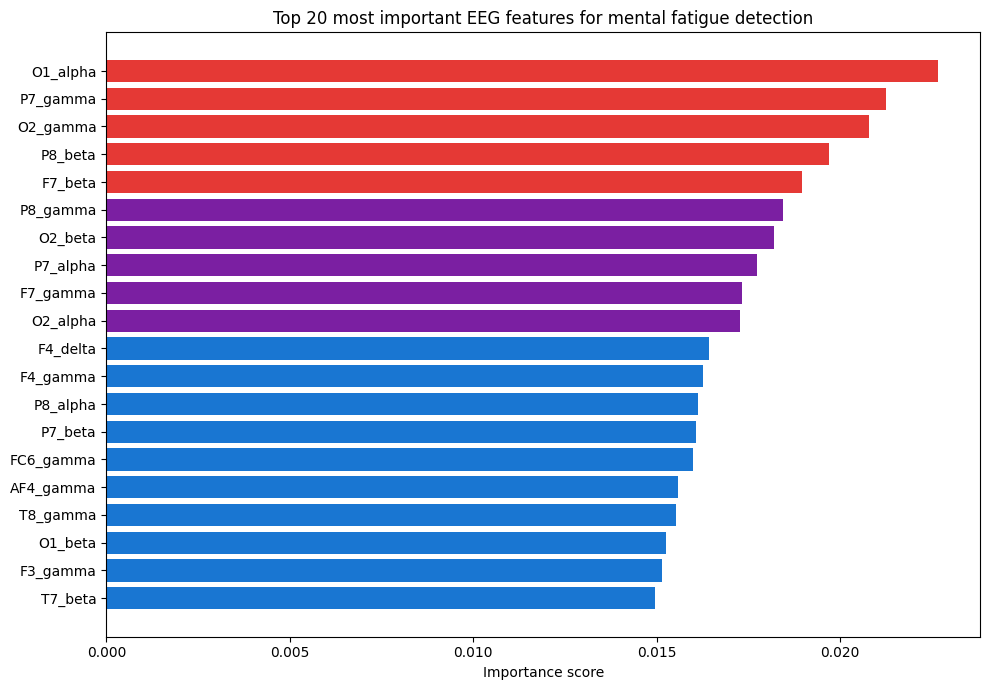

Plot saved to Google Drive!


In [11]:
# 9. Visualize top 20 features

top20 = importance_df.head(20)

plt.figure(figsize=(10, 7))
colors = ['#E53935' if i < 5 else '#7B1FA2' if i < 10 else '#1976D2'
          for i in range(len(top20))]
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors[::-1])
plt.xlabel('Importance score')
plt.title('Top 20 most important EEG features for mental fatigue detection')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Thesis/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Google Drive!")

=== Channel importance ranking ===

   channel  total_importance
0       P7          0.081381
1       O2          0.080878
2       P8          0.079350
3       O1          0.076982
4       F7          0.073146
5       F4          0.071899
6       F3          0.070066
7       T7          0.069644
8       T8          0.068971
9      AF4          0.067478
10     FC6          0.066758
11     AF3          0.066449
12     FC5          0.064143
13      F8          0.062854


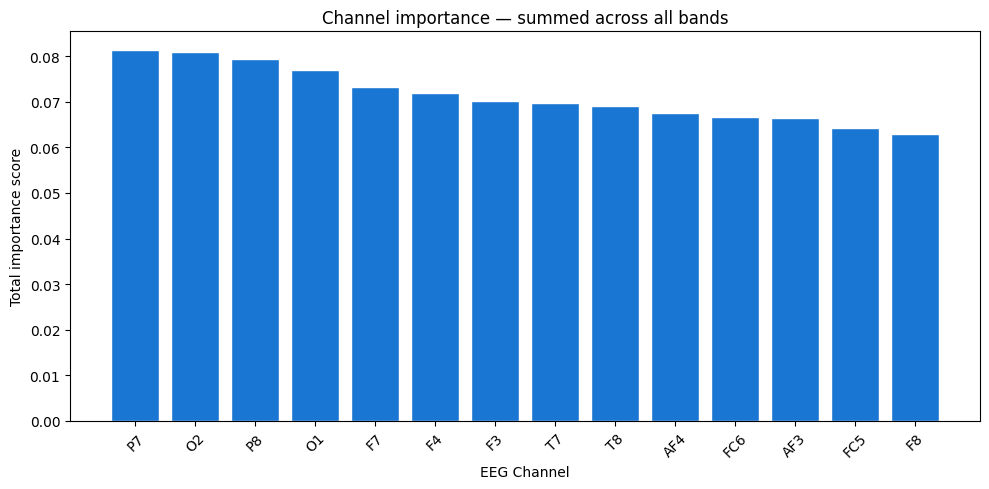

Plot saved to Google Drive!


In [12]:
# 10. Extract top channels

# Extract channel name from feature name
# e.g. "AF3_delta" → "AF3", "O1_alpha" → "O1"
importance_df['channel'] = importance_df['feature'].apply(
    lambda x: x.split('_')[0]
)
importance_df['band'] = importance_df['feature'].apply(
    lambda x: x.split('_')[1]
)

# Sum importance scores per channel
channel_importance = importance_df.groupby('channel')['importance'].sum()\
                                  .sort_values(ascending=False)\
                                  .reset_index()
channel_importance.columns = ['channel', 'total_importance']

print("=== Channel importance ranking ===\n")
print(channel_importance.to_string())

# Plot channel importance
plt.figure(figsize=(10, 5))
plt.bar(channel_importance['channel'],
        channel_importance['total_importance'],
        color='#1976D2', edgecolor='white')
plt.xlabel('EEG Channel')
plt.ylabel('Total importance score')
plt.title('Channel importance — summed across all bands')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Thesis/channel_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Google Drive!")

In [13]:
# 11. Select top channels and filter features

# Select top N channels — we use 6 as a starting point
# This is adjustable — we can try 4, 6, 8 and compare
TOP_N_CHANNELS = 6

top_channels = channel_importance['channel'].head(TOP_N_CHANNELS).tolist()
print(f"Top {TOP_N_CHANNELS} channels selected: {top_channels}")

# Keep only features belonging to top channels
selected_features = [col for col in feature_cols
                     if col.split('_')[0] in top_channels]

print(f"\nFeatures kept: {len(selected_features)} out of {len(feature_cols)}")
print(f"Features dropped: {len(feature_cols) - len(selected_features)}")
print(f"\nSelected features:\n{selected_features}")

# Apply to both secondary and primary data
X_selected = secondary_df[selected_features].values
X_primary  = primary_df[selected_features].values
y_secondary = secondary_df['label'].values

print(f"\nFinal X_selected shape: {X_selected.shape}")
print(f"Final X_primary shape:  {X_primary.shape}")

Top 6 channels selected: ['P7', 'O2', 'P8', 'O1', 'F7', 'F4']

Features kept: 30 out of 70
Features dropped: 40

Selected features:
['F4_delta', 'F7_delta', 'P7_delta', 'P8_delta', 'O1_delta', 'O2_delta', 'F4_theta', 'F7_theta', 'P7_theta', 'P8_theta', 'O1_theta', 'O2_theta', 'F4_alpha', 'F7_alpha', 'P7_alpha', 'P8_alpha', 'O1_alpha', 'O2_alpha', 'F4_beta', 'F7_beta', 'P7_beta', 'P8_beta', 'O1_beta', 'O2_beta', 'F4_gamma', 'F7_gamma', 'P7_gamma', 'P8_gamma', 'O1_gamma', 'O2_gamma']

Final X_selected shape: (2051, 30)
Final X_primary shape:  (294, 30)


In [14]:
# 12. Normalize features

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# IMPORTANT: fit ONLY on secondary data, then transform both
X_scaled_secondary = scaler.fit_transform(X_selected)
X_scaled_primary   = scaler.transform(X_primary)

print("Scaling complete!")
print(f"Secondary data — mean (should be ~0): {X_scaled_secondary.mean():.4f}")
print(f"Secondary data — std  (should be ~1): {X_scaled_secondary.std():.4f}")
print(f"Primary data   — mean: {X_scaled_primary.mean():.4f}")
print(f"Primary data   — std:  {X_scaled_primary.std():.4f}")

Scaling complete!
Secondary data — mean (should be ~0): 0.0000
Secondary data — std  (should be ~1): 1.0000
Primary data   — mean: -0.0000
Primary data   — std:  1.0000


In [17]:
# 14. (Updated) Define all 4 models

models = {
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42,
        probability=True
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )
}

print("4 models defined:")
for name in models:
    print(f"  - {name}")

4 models defined:
  - SVM
  - Random Forest
  - XGBoost
  - MLP Neural Network


In [35]:
# 30. Run all models on primary data

print("=== Primary Data Predictions (4 subjects) ===\n")

primary_predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_scaled_primary)
    y_prob = model.predict_proba(X_scaled_primary)[:, 1]

    primary_predictions[name] = {
        'predictions': y_pred,
        'probabilities': y_prob
    }

    alert_count    = (y_pred == 0).sum()
    fatigue_count  = (y_pred == 1).sum()
    alert_pct      = alert_count / len(y_pred) * 100
    fatigue_pct    = fatigue_count / len(y_pred) * 100

    print(f"--- {name} ---")
    print(f"  Alert (0):   {alert_count} epochs ({alert_pct:.1f}%)")
    print(f"  Fatigued (1): {fatigue_count} epochs ({fatigue_pct:.1f}%)")
    print()

print("Predictions complete!")

=== Primary Data Predictions (4 subjects) ===

--- SVM ---
  Alert (0):   157 epochs (53.4%)
  Fatigued (1): 137 epochs (46.6%)

--- Random Forest ---
  Alert (0):   195 epochs (66.3%)
  Fatigued (1): 99 epochs (33.7%)

--- XGBoost ---
  Alert (0):   228 epochs (77.6%)
  Fatigued (1): 66 epochs (22.4%)

--- MLP Neural Network ---
  Alert (0):   192 epochs (65.3%)
  Fatigued (1): 102 epochs (34.7%)

Predictions complete!


In [36]:
#31. Per-subject prediction breakdown

print("=== Per-subject fatigue detection (primary data) ===\n")

# Add best model predictions to primary dataframe
best_model_name = 'Random Forest'
primary_df['predicted_label'] = primary_predictions[best_model_name]['predictions']
primary_df['fatigue_probability'] = primary_predictions[best_model_name]['probabilities']

# Per subject summary
subject_summary = []

for subject in sorted(primary_df['subject'].unique()):
    subj_df       = primary_df[primary_df['subject'] == subject]
    total         = len(subj_df)
    fatigued      = (subj_df['predicted_label'] == 1).sum()
    alert         = (subj_df['predicted_label'] == 0).sum()
    fatigue_pct   = fatigued / total * 100
    avg_prob      = subj_df['fatigue_probability'].mean()

    subject_summary.append({
        'Subject':           subject.replace('_features_bandpower_z.csv', ''),
        'Total epochs':      total,
        'Alert epochs':      alert,
        'Fatigued epochs':   fatigued,
        'Fatigue %':         f"{fatigue_pct:.1f}%",
        'Avg fatigue prob':  f"{avg_prob:.4f}"
    })

    print(f"Subject: {subject.replace('_features_bandpower_z.csv', '')}")
    print(f"  Total epochs:    {total}")
    print(f"  Alert:           {alert} ({100-fatigue_pct:.1f}%)")
    print(f"  Fatigued:        {fatigued} ({fatigue_pct:.1f}%)")
    print(f"  Avg probability: {avg_prob:.4f}")
    print()

subject_summary_df = pd.DataFrame(subject_summary)
subject_summary_df.to_csv(
    '/content/drive/MyDrive/EEG_Thesis/primary_predictions.csv',
    index=False
)
print("Per-subject summary saved to Google Drive!")

=== Per-subject fatigue detection (primary data) ===

Subject: S1
  Total epochs:    84
  Alert:           65 (77.4%)
  Fatigued:        19 (22.6%)
  Avg probability: 0.4610

Subject: S2
  Total epochs:    77
  Alert:           55 (71.4%)
  Fatigued:        22 (28.6%)
  Avg probability: 0.4612

Subject: S3
  Total epochs:    52
  Alert:           25 (48.1%)
  Fatigued:        27 (51.9%)
  Avg probability: 0.4915

Subject: S4
  Total epochs:    81
  Alert:           50 (61.7%)
  Fatigued:        31 (38.3%)
  Avg probability: 0.4789

Per-subject summary saved to Google Drive!


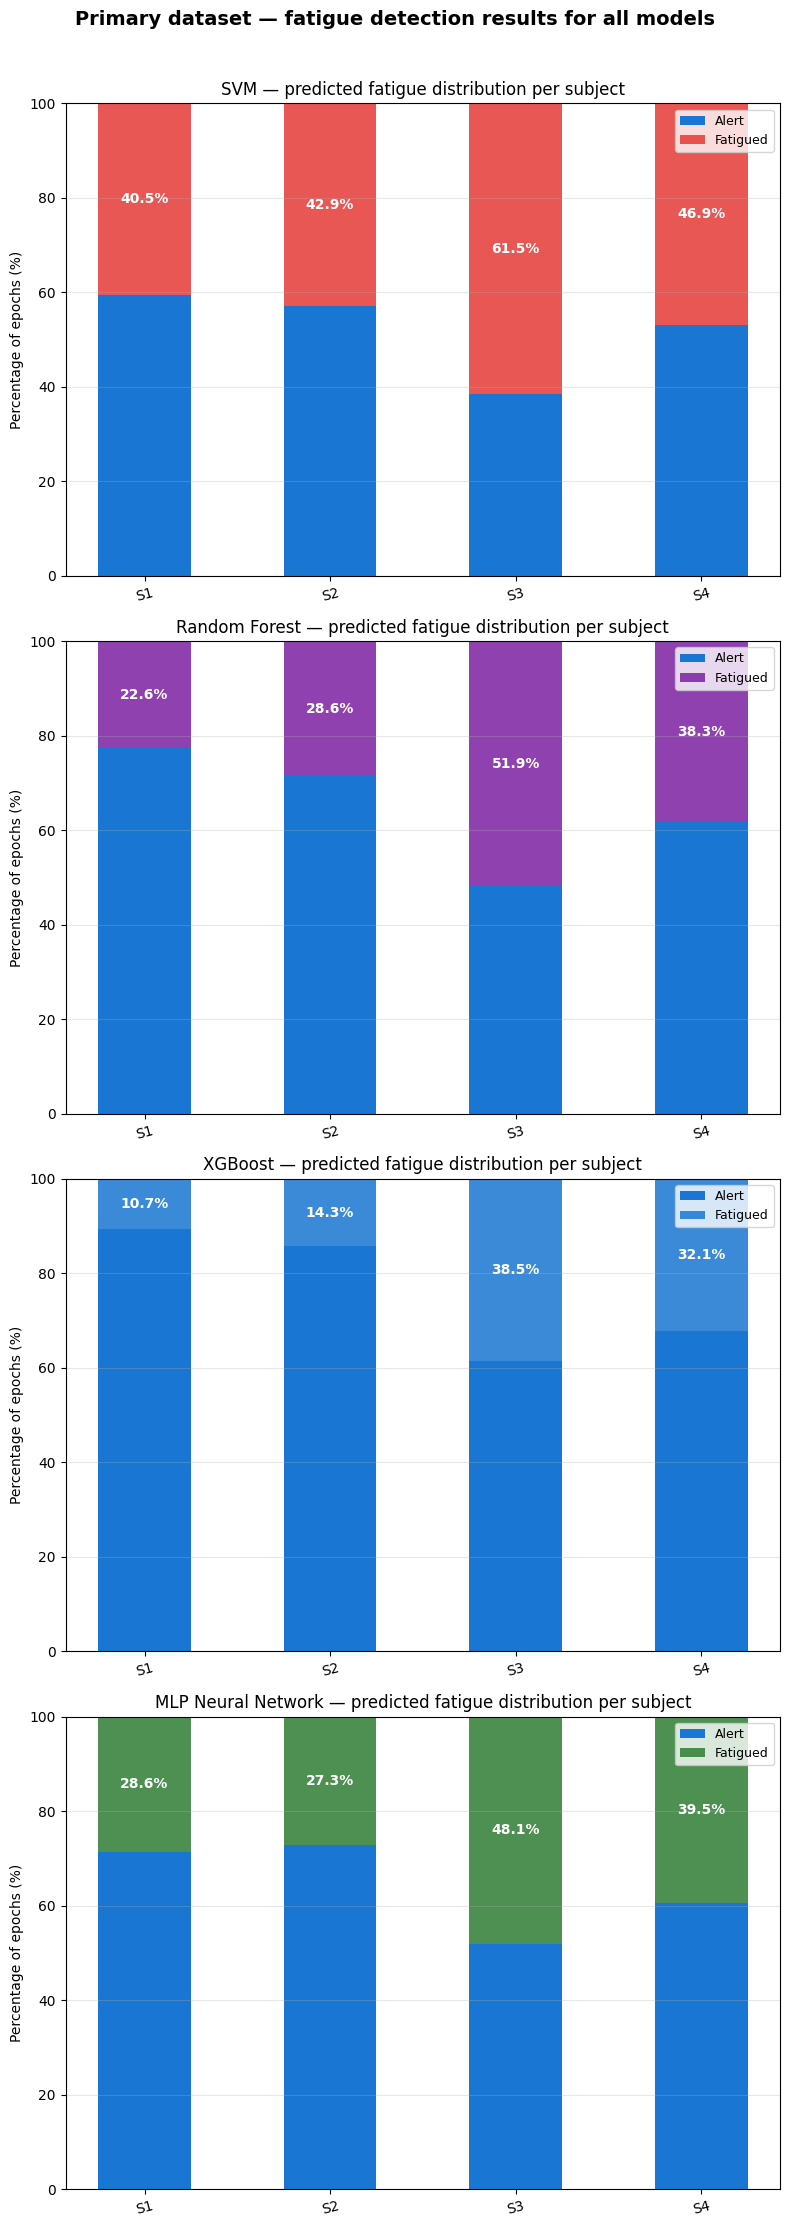

All-model primary prediction plots saved to Google Drive!


In [ ]:
# 32 (Updated): Visualize primary predictions for all 4 models

fig, axes = plt.subplots(4, 1, figsize=(8, 22))
model_names = list(primary_predictions.keys())
colors_model = ['#E53935', '#7B1FA2', '#1976D2', '#2E7D32']

for row_idx, (name, color) in enumerate(zip(model_names, colors_model)):

    # Get predictions for this model
    preds = primary_predictions[name]['predictions']
    probs = primary_predictions[name]['probabilities']

    # Build per-subject summary for this model
    subj_data = []
    for subject in sorted(primary_df['subject'].unique()):
        mask         = primary_df['subject'].eq(subject).values
        subj_preds   = preds[mask]
        subj_probs   = probs[mask]
        total        = len(subj_preds)
        fatigued     = (subj_preds == 1).sum()
        alert        = (subj_preds == 0).sum()
        fatigue_pct  = fatigued / total * 100
        alert_pct    = 100 - fatigue_pct
        avg_prob     = subj_probs.mean()
        subj_label   = subject.replace('_features_bandpower_z.csv', '')

        subj_data.append({
            'subject':     subj_label,
            'alert_pct':   alert_pct,
            'fatigue_pct': fatigue_pct,
        })

    subjects_list = [d['subject']     for d in subj_data]
    alert_pcts    = [d['alert_pct']   for d in subj_data]
    fatigue_pcts  = [d['fatigue_pct'] for d in subj_data]
    x             = np.arange(len(subjects_list))

    # --- Stacked bar chart ---
    ax = axes[row_idx]
    bars_alert   = ax.bar(x, alert_pcts,
                          width=0.5,
                          color='#1976D2',
                          label='Alert')
    bars_fatigue = ax.bar(x, fatigue_pcts,
                          bottom=alert_pcts,
                          width=0.5,
                          color=color,
                          label='Fatigued',
                          alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(subjects_list, rotation=15)
    ax.set_ylabel('Percentage of epochs (%)')
    ax.set_title(f'{name} — predicted fatigue distribution per subject')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add percentage labels inside fatigued bars
    for bar, pct in zip(bars_fatigue, fatigue_pcts):
        if pct > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%',
                ha='center', va='center',
                color='white', fontsize=10,
                fontweight='bold'
            )

plt.suptitle('Primary dataset — fatigue detection results for all models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Thesis/primary_all_models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("All-model primary prediction plots saved to Google Drive!")

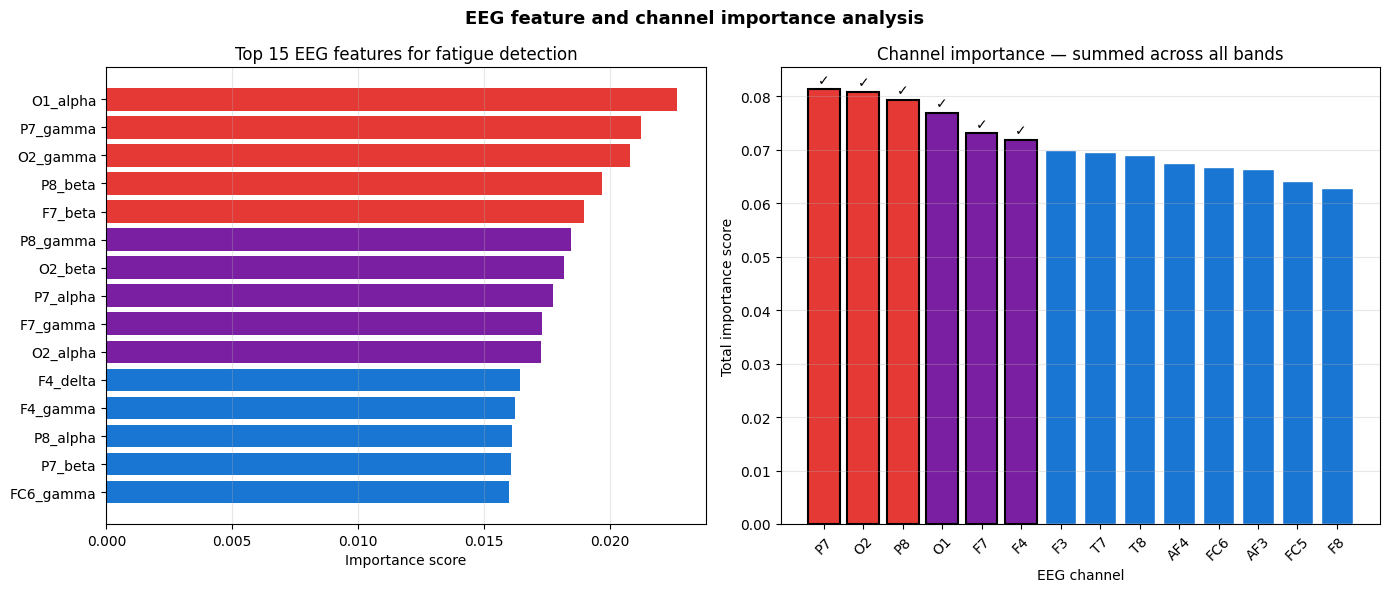

Feature importance plot saved!


In [ ]:
# 35. Feature importance plot (final version)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 features
top15 = importance_df.head(15)
colors_feat = ['#E53935' if i < 5 else '#7B1FA2' if i < 10 else '#1976D2'
               for i in range(len(top15))]

axes[0].barh(top15['feature'][::-1],
             top15['importance'][::-1],
             color=colors_feat[::-1])
axes[0].set_xlabel('Importance score')
axes[0].set_title('Top 15 EEG features for fatigue detection')
axes[0].grid(axis='x', alpha=0.3)

# Channel importance
colors_ch = ['#E53935' if i < 3 else '#7B1FA2' if i < 6 else '#1976D2'
             for i in range(len(channel_importance))]

axes[1].bar(channel_importance['channel'],
            channel_importance['total_importance'],
            color=colors_ch, edgecolor='white')
axes[1].set_xlabel('EEG channel')
axes[1].set_ylabel('Total importance score')
axes[1].set_title('Channel importance — summed across all bands')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Highlight selected channels
for i, (bar, ch) in enumerate(zip(axes[1].patches,
                                   channel_importance['channel'])):
    if ch in top_channels:
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5)
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.001,
                     '✓', ha='center',
                     fontsize=10, color='black')

plt.suptitle('EEG feature and channel importance analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Thesis/feature_channel_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")